# ImageNet-pretrained ResNet-18

This notebook fine-tunes an ImageNet-pretrained ResNet-18 on the same agreed 500-species split as the scratch baseline. The official iNaturalist validation subset is kept untouched until the final evaluation.

## Runtime setup

For Colab, put `selected_images.tar.gz` (or `selected_images.tar`) in `MyDrive/COMP9517` and select a GPU runtime. The setup below clones the public repository when needed, installs its dependencies, mounts Drive, and extracts the dataset to the runtime's local disk.

In [ ]:
from pathlib import Path
import sys

candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (path.resolve() for path in candidates if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Open this notebook from a local project checkout.")
sys.path.insert(0, str(REPO_ROOT / "src"))

from inat_project.paths import get_project_paths, require_dataset

PATHS = get_project_paths(REPO_ROOT)
DATA_ROOT = require_dataset(PATHS)
METADATA_ROOT = PATHS.metadata_root
CHECKPOINT_ROOT = PATHS.checkpoint_root
print(f"Repository:  {REPO_ROOT}")
print(f"Data:        {DATA_ROOT}")
print(f"Checkpoints: {CHECKPOINT_ROOT}")


In [ ]:
# Paths are configured by the previous local setup cell.


In [3]:
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn

from inat_project.config import load_config
from inat_project.data import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    build_split_manifests,
    create_dataloaders,
    validate_manifests,
)
from inat_project.evaluation import (
    collect_predictions,
    confusion_data,
    most_confused_pairs,
    save_metrics,
    summarise_predictions,
)
from inat_project.models import create_resnet18
from inat_project.plots import (
    plot_confused_pairs,
    plot_confusion_matrix,
    plot_training_history,
)
from inat_project.training import (
    evaluate_one_epoch,
    get_device,
    load_checkpoint,
    make_grad_scaler,
    save_checkpoint,
    seed_everything,
    train_one_epoch,
)

## Configuration and data split

In [ ]:
config = load_config(REPO_ROOT / "configs/resnet18_pretrained.yaml")
seed_everything(config["seed"])

RESULT_ROOT = PATHS.results_root / "pretrained"
FIGURE_ROOT = RESULT_ROOT / "figures"
RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

config


In [5]:
data_config = config["data"]
manifest_paths = build_split_manifests(
    DATA_ROOT,
    METADATA_ROOT,
    seed=config["seed"],
    expected_classes=data_config["num_classes"],
    train_per_class=data_config["train_per_class"],
    validation_per_class=data_config["validation_per_class"],
    test_per_class=data_config["test_per_class"],
)
split_counts = validate_manifests(
    METADATA_ROOT, expected_classes=data_config["num_classes"]
)
split_counts.describe().loc[["min", "max"]]

split,test,train,validation
min,10.0,40.0,10.0
max,10.0,40.0,10.0


In [6]:
device = get_device()
num_workers = data_config["num_workers"] if device.type != "mps" else 0
loaders = create_dataloaders(
    DATA_ROOT,
    METADATA_ROOT,
    batch_size=data_config["batch_size"],
    image_size=data_config["image_size"],
    num_workers=num_workers,
    seed=config["seed"],
    pin_memory=device.type == "cuda",
)

with open(manifest_paths["class_to_idx"], encoding="utf-8") as handle:
    class_to_idx = json.load(handle)
idx_to_class = {index: name for name, index in class_to_idx.items()}

print(f"Device: {device}")
for split_name, loader in loaders.items():
    print(f"{split_name:>10}: {len(loader.dataset):,} images, {len(loader):,} batches")

Device: mps
     train: 20,000 images, 313 batches
validation: 5,000 images, 79 batches
      test: 5,000 images, 79 batches


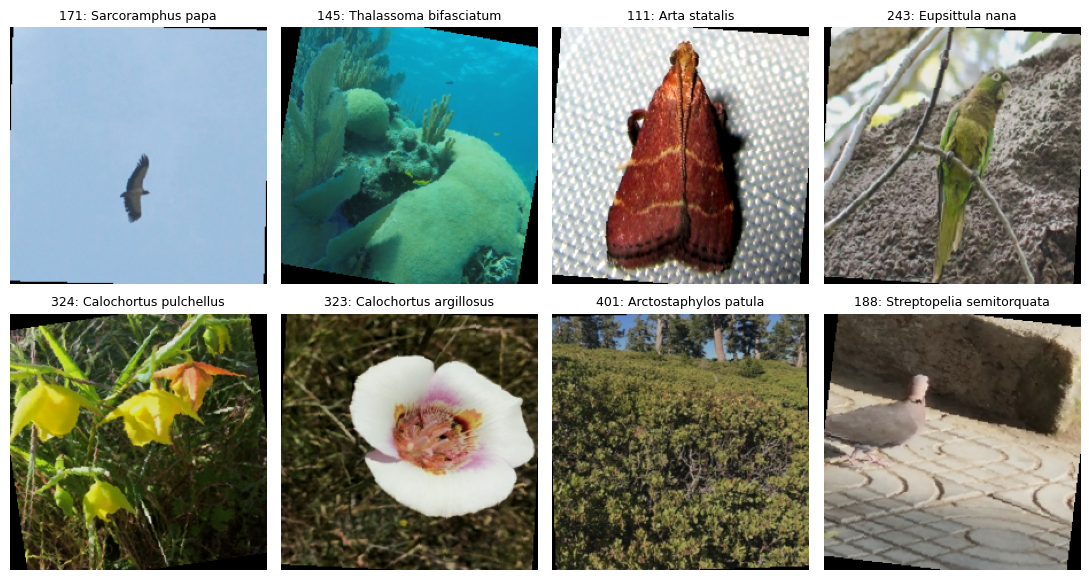

In [7]:
images, labels = next(iter(loaders["train"]))
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

figure, axes = plt.subplots(2, 4, figsize=(11, 6))
for axis, image, label in zip(axes.flat, images[:8], labels[:8]):
    shown = (image * std + mean).clamp(0, 1).permute(1, 2, 0)
    species = " ".join(idx_to_class[int(label)].split("_")[-2:])
    axis.imshow(shown)
    axis.set_title(f"{int(label)}: {species}", fontsize=9)
    axis.axis("off")
figure.tight_layout()

## Model and training

ImageNet weights initialise the feature extractor. The 500-class output layer is newly initialised, and the complete network is fine-tuned with AdamW.

In [8]:
training_config = config["training"]
model = create_resnet18(
    num_classes=data_config["num_classes"],
    pretrained=config["model"]["pretrained"],
).to(device)

assert config["model"]["pretrained"] is True
criterion = nn.CrossEntropyLoss(
    label_smoothing=training_config["label_smoothing"]
)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["learning_rate"],
    weight_decay=training_config["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=training_config["epochs"],
    eta_min=config["scheduler"]["minimum_learning_rate"],
)
use_amp = bool(training_config["use_amp"] and device.type == "cuda")
scaler = make_grad_scaler(use_amp)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Parameters: {parameter_count:,}")
print(f"CUDA mixed precision: {use_amp}")

Parameters: 11,433,012
CUDA mixed precision: False


In [9]:
latest_checkpoint = CHECKPOINT_ROOT / "resnet18_pretrained_latest.pt"
best_checkpoint = CHECKPOINT_ROOT / "resnet18_pretrained_best.pt"
RESUME = True

start_epoch = 0
history = []
best_validation_loss = float("inf")
epochs_without_improvement = 0

if RESUME and latest_checkpoint.exists():
    saved = load_checkpoint(
        latest_checkpoint,
        model,
        device=device,
        optimizer=optimizer,
        scheduler=scheduler,
    )
    if saved["class_to_idx"] != class_to_idx:
        raise ValueError("Checkpoint label mapping does not match this dataset.")
    start_epoch = saved["epoch"] + 1
    history = saved.get("history", [])
    best_validation_loss = saved.get("best_validation_loss", float("inf"))
    if history:
        best_epoch = min(history, key=lambda row: row["validation_loss"])["epoch"]
        epochs_without_improvement = history[-1]["epoch"] - best_epoch
    print(f"Resuming from epoch {start_epoch + 1}")
else:
    print("Starting a new training run")

Starting a new training run


In [10]:
for epoch in range(start_epoch, training_config["epochs"]):
    epoch_start = time.perf_counter()
    train_metrics = train_one_epoch(
        model,
        loaders["train"],
        criterion,
        optimizer,
        device,
        scaler=scaler,
        use_amp=use_amp,
    )
    validation_metrics = evaluate_one_epoch(
        model, loaders["validation"], criterion, device
    )
    scheduler.step()

    row = {
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_top1": train_metrics["top1"],
        "train_top5": train_metrics["top5"],
        "validation_loss": validation_metrics["loss"],
        "validation_top1": validation_metrics["top1"],
        "validation_top5": validation_metrics["top5"],
        "learning_rate": optimizer.param_groups[0]["lr"],
        "epoch_seconds": time.perf_counter() - epoch_start,
    }
    history.append(row)

    improved = validation_metrics["loss"] < best_validation_loss
    if improved:
        best_validation_loss = validation_metrics["loss"]
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    save_args = dict(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        best_validation_loss=best_validation_loss,
        history=history,
        class_to_idx=class_to_idx,
        config=config,
    )
    save_checkpoint(latest_checkpoint, **save_args)
    if improved:
        save_checkpoint(best_checkpoint, **save_args)

    print(
        f"Epoch {epoch + 1:02d}/{training_config['epochs']} | "
        f"train loss {row['train_loss']:.3f}, top-1 {row['train_top1']:.3f} | "
        f"val loss {row['validation_loss']:.3f}, top-1 {row['validation_top1']:.3f} | "
        f"{row['epoch_seconds'] / 60:.1f} min"
    )

    if epochs_without_improvement >= training_config["early_stopping_patience"]:
        print("Stopping because validation loss has not improved.")
        break

train:   0%|          | 0/313 [00:00<?, ?it/s]

validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01/30 | train loss 4.728, top-1 0.185 | val loss 3.700, top-1 0.335 | 4.0 min


train:   0%|          | 0/313 [00:00<?, ?it/s]

validation:   0%|          | 0/79 [00:00<?, ?it/s]

...

validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 29/30 | train loss 1.053, top-1 1.000 | val loss 2.470, top-1 0.665 | 4.3 min


train:   0%|          | 0/313 [00:00<?, ?it/s]

validation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 30/30 | train loss 1.052, top-1 1.000 | val loss 2.471, top-1 0.667 | 4.3 min
Stopping because validation loss has not improved.


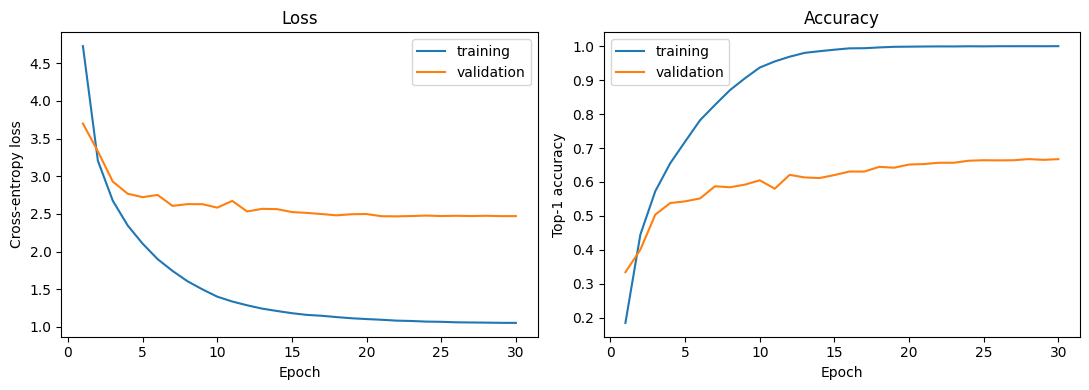

In [11]:
history_frame = pd.DataFrame(history)
history_frame.to_csv(RESULT_ROOT / "training_history.csv", index=False)
plot_training_history(history, FIGURE_ROOT / "training_curves.png")
plt.show()

## Held-out test evaluation

The best validation checkpoint is loaded once. No hyperparameters are changed after inspecting these results.

In [12]:
best_saved = load_checkpoint(best_checkpoint, model, device=device)
predictions, inference_seconds = collect_predictions(
    model, loaders["test"], device
)
metrics = summarise_predictions(
    predictions,
    num_classes=data_config["num_classes"],
    inference_seconds=inference_seconds,
)
metrics["training_seconds"] = float(
    sum(row["epoch_seconds"] for row in best_saved["history"])
)
metrics["best_epoch"] = int(best_saved["epoch"] + 1)

predictions["true_class"] = predictions["true_idx"].map(idx_to_class)
predictions["predicted_class"] = predictions["predicted_idx"].map(idx_to_class)
predictions.to_csv(RESULT_ROOT / "test_predictions.csv", index=False)
save_metrics(metrics, RESULT_ROOT / "metrics.json")
pd.Series(metrics, name="value").to_frame()

test:   0%|          | 0/79 [00:00<?, ?it/s]

,value
top1_accuracy,0.660200
overall_accuracy,0.660200
top5_accuracy,0.833000
balanced_accuracy,0.660200
macro_precision,0.677513
macro_recall,0.660200
macro_f1,0.657578
test_images,5000.000000
inference_seconds,22.989300
images_per_second,217.492488


## Comparison with the scratch baseline

In [13]:
scratch_metrics_path = RESULT_ROOT.parent / "scratch" / "metrics.json"
if scratch_metrics_path.is_file():
    with scratch_metrics_path.open(encoding="utf-8") as handle:
        scratch_metrics = json.load(handle)

    comparison_metrics = [
        "top1_accuracy",
        "top5_accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
    comparison = pd.DataFrame(
        {
            "scratch_percent": [100 * scratch_metrics[name] for name in comparison_metrics],
            "pretrained_percent": [100 * metrics[name] for name in comparison_metrics],
        },
        index=comparison_metrics,
    )
    comparison["improvement_points"] = (
        comparison["pretrained_percent"] - comparison["scratch_percent"]
    )
    display(comparison.round(2))
else:
    print(f"Scratch metrics not found at {scratch_metrics_path}")

,scratch_percent,pretrained_percent,improvement_points
top1_accuracy,41.98,66.02,24.04
top5_accuracy,63.46,83.30,19.84
balanced_accuracy,41.98,66.02,24.04
macro_precision,42.42,67.75,25.33
macro_recall,41.98,66.02,24.04
macro_f1,41.28,65.76,24.48


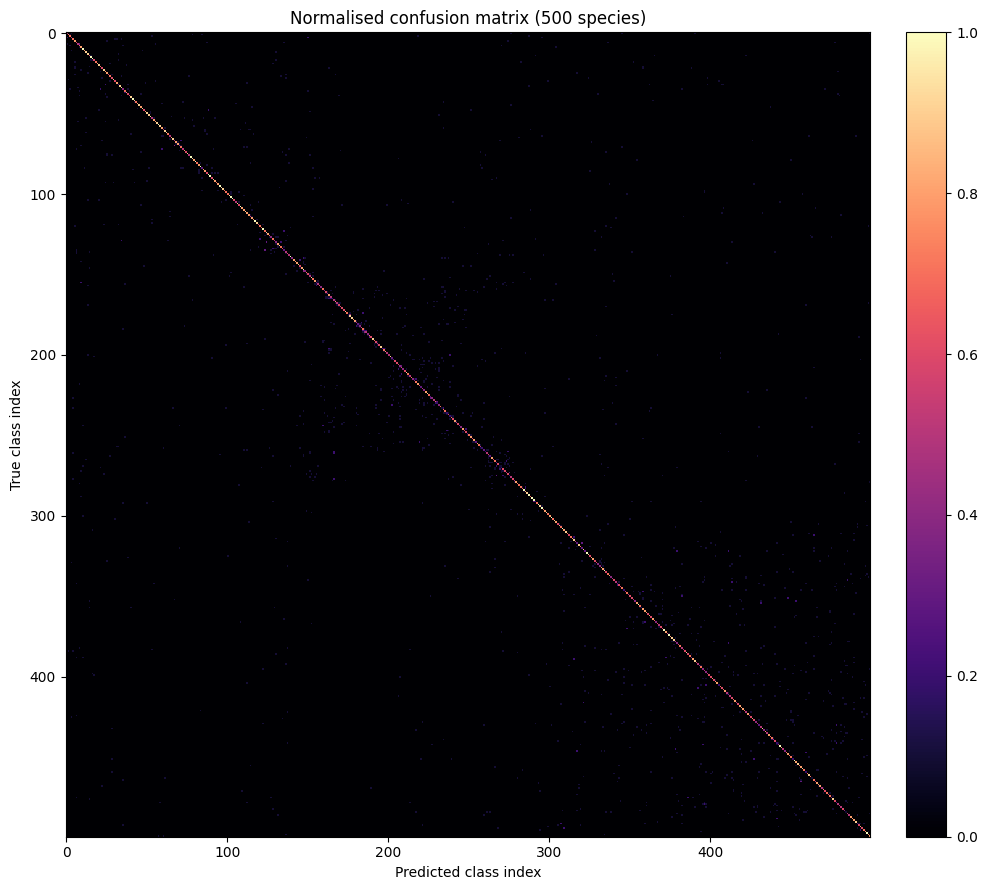

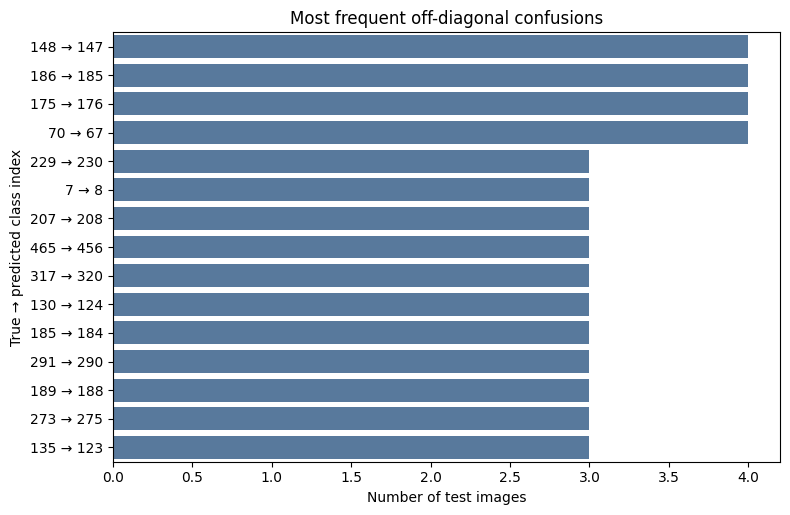

,true_idx,predicted_idx,true_class,predicted_class,count
0,148,147,02859_Animalia_Chordata_Actinopterygii_Percifo...,02852_Animalia_Chordata_Actinopterygii_Percifo...,4
1,186,185,03495_Animalia_Chordata_Aves_Charadriiformes_S...,03482_Animalia_Chordata_Aves_Charadriiformes_S...,4
2,175,176,03361_Animalia_Chordata_Aves_Charadriiformes_C...,03364_Animalia_Chordata_Aves_Charadriiformes_C...,4
3,70,67,01395_Animalia_Arthropoda_Insecta_Lepidoptera_...,01339_Animalia_Arthropoda_Insecta_Lepidoptera_...,4
4,229,230,04300_Animalia_Chordata_Aves_Passeriformes_Tyr...,04304_Animalia_Chordata_Aves_Passeriformes_Tyr...,3
5,7,8,00118_Animalia_Arthropoda_Arachnida_Araneae_Th...,00121_Animalia_Arthropoda_Arachnida_Araneae_Th...,3
6,207,208,03937_Animalia_Chordata_Aves_Passeriformes_Mel...,03941_Animalia_Chordata_Aves_Passeriformes_Mim...,3
7,465,456,09117_Plantae_Tracheophyta_Magnoliopsida_Piper...,08898_Plantae_Tracheophyta_Magnoliopsida_Malpi...,3
8,317,320,06023_Plantae_Tracheophyta_Liliopsida_Asparaga...,06075_Plantae_Tracheophyta_Liliopsida_Asparaga...,3
9,130,124,02500_Animalia_Arthropoda_Insecta_Odonata_Libe...,02406_Animalia_Arthropoda_Insecta_Odonata_Cord...,3


In [14]:
matrix, normalised_matrix = confusion_data(
    predictions, data_config["num_classes"]
)
pairs = most_confused_pairs(matrix, idx_to_class, limit=30)
pairs.to_csv(RESULT_ROOT / "confused_pairs.csv", index=False)

plot_confusion_matrix(
    normalised_matrix, FIGURE_ROOT / "confusion_matrix.png"
)
plt.show()
plot_confused_pairs(pairs, FIGURE_ROOT / "confused_pairs.png")
plt.show()
pairs.head(20)

## Run notes

Record the GPU type, total runtime, interruptions/resumptions, and the epoch selected by validation loss. Compare these results directly with the scratch baseline using the same held-out test split.

In [15]:
runtime_details = {
    "torch_version": torch.__version__,
    "device": str(device),
    "device_name": (
        torch.cuda.get_device_name(0) if device.type == "cuda" else str(device)
    ),
}
with (RESULT_ROOT / "runtime.json").open("w", encoding="utf-8") as handle:
    json.dump(runtime_details, handle, indent=2)
runtime_details

{'torch_version': '2.13.0', 'device': 'mps', 'device_name': 'mps'}